# Portfolio Project: Visualization in Python - Canada Immigration Analytics

---

# 02 — Exploratory Visual Analytics of Canadian Immigration

## Purpose

This notebook is a **question-driven visual analysis** on immigration to Canada from **1980 through 2013**.

### Analytical questions

1. How did total identified international immigration to Canada change over time?
2. Which origin countries contributed the most immigrants over the full period?
3. How did the trajectories of the largest origin countries differ?
4. How did the continental composition of immigration change over time?
5. How unevenly was immigration distributed across origin countries?
6. How concentrated were total immigrant flows among the largest origins?
7. Which major origin countries exhibited the greatest year-to-year variability?

The notebook uses **Pandas for data transformation** and **Matplotlib for visualization**.


### Workbook Structure

`Canada.xlsx` contains three worksheets:

1. **`Regions by Citizenship`** — region-level information and source metadata;
2. **`Canada by Citizenship`** — the original country/citizenship table with the UN metadata header;
3. **`Canada by Citizenship (2)`** — a simplified tabular version of the same country-level structure.

This notebook uses **`Canada by Citizenship`** because it preserves the original source metadata and provides a transparent connection between the analytical dataset and the underlying UN workbook.

The first 20 rows contain source information, classification details, and workbook metadata rather than country-level observations. The tabular immigration records begin immediately after this metadata section. The preprocessing workflow therefore skips these header rows when importing the analytical table while retaining `Canada.xlsx` itself as the project's authoritative raw-data source.


## 1. Load the analysis-ready dataset

Notebook 01 created the cleaned country-level dataset used here.  
The analysis therefore begins from a consistent, validated source.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_CANDIDATES = [
    Path("data") / "canada_immigration_clean.csv",
    Path("canada_immigration_clean.csv"),
]

DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "The cleaned dataset was not found. Run Notebook 01 first or place "
        "canada_immigration_clean.csv in the notebook directory or data/ subdirectory."
    )

df = pd.read_csv(DATA_PATH)
years = [str(year) for year in range(1980, 2014)]
year_values = np.arange(1980, 2014)

df_can = df.set_index("Country")

print(f"Loaded: {DATA_PATH}")
print(f"Dataset shape: {df.shape[0]} origins × {df.shape[1]} columns")
display(df.head(3))


Loaded: data/canada_immigration_clean.csv
Dataset shape: 194 origins × 39 columns


,Country,Continent,Region,Development_Group,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
0,Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,496,741,828,1076,1028,1378,1170,713,858,1537,2212,2555,1999,2395,3326,4067,3697,3479,2978,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
1,Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,1,2,2,3,3,21,56,96,71,63,113,307,574,1264,1816,1602,1021,853,1450,1223,856,702,560,716,561,539,620,603,15699
2,Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,69,132,242,434,491,872,795,717,595,1106,2054,1842,2292,2389,2867,3418,3406,3072,3616,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439


In [2]:
# Lightweight validation of the input expected from Notebook 01.
required_columns = {
    "Country", "Continent", "Region", "Development_Group", "Total", *years
}

assert required_columns.issubset(df.columns)
assert df["Country"].is_unique
assert df[years].isna().sum().sum() == 0
assert (df[years] >= 0).all().all()

print("Input validation passed.")


Input validation passed.


## 2. How did total immigration change over time?

A line chart is the most direct representation because the x-axis is an ordered time dimension and the analytical focus is the shape of the overall trend.

The annual series aggregates all identified international origins retained in Notebook 01.


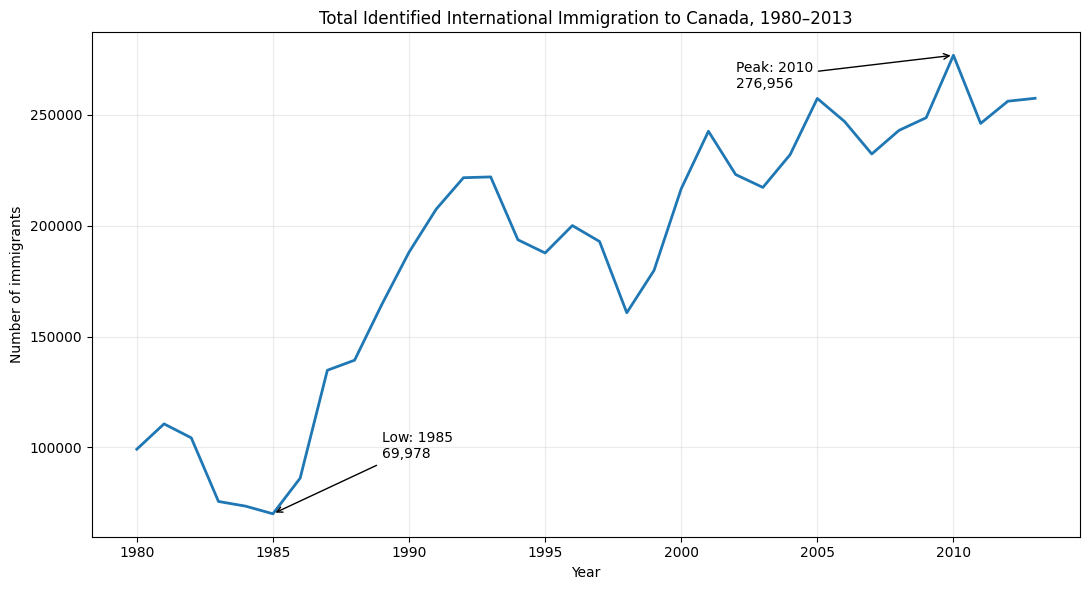

Annual immigration increased from 99,137 in 1980 to 257,535 in 2013. The highest annual total was 276,956 in 2010.


In [3]:
annual_total = df[years].sum(axis=0)
annual_total.index = annual_total.index.astype(int)

peak_year = int(annual_total.idxmax())
peak_value = int(annual_total.max())
lowest_year = int(annual_total.idxmin())
lowest_value = int(annual_total.min())

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(annual_total.index, annual_total.values, linewidth=2)

ax.set_title("Total Identified International Immigration to Canada, 1980–2013")
ax.set_xlabel("Year")
ax.set_ylabel("Number of immigrants")
ax.grid(alpha=0.25)

ax.annotate(
    f"Peak: {peak_year}\n{peak_value:,}",
    xy=(peak_year, peak_value),
    xytext=(peak_year - 8, peak_value - 15000),
    arrowprops={"arrowstyle": "->"},
)

ax.annotate(
    f"Low: {lowest_year}\n{lowest_value:,}",
    xy=(lowest_year, lowest_value),
    xytext=(lowest_year + 4, lowest_value + 25000),
    arrowprops={"arrowstyle": "->"},
)

plt.tight_layout()
plt.show()

print(
    f"Annual immigration increased from {annual_total.loc[1980]:,} in 1980 "
    f"to {annual_total.loc[2013]:,} in 2013. "
    f"The highest annual total was {peak_value:,} in {peak_year}."
)


### Interpretation

The aggregate series is not a smooth linear increase. It contains pronounced rises, declines, and recoveries, indicating that immigration flows changed substantially across the observation window.

The key point is therefore not simply that immigration was higher by 2013 than in 1980, but that the system experienced **distinct phases rather than one constant growth path**. This motivates examining which origin countries and regions drove those changes.


## 3. Which countries contributed the most immigrants?

A sorted horizontal bar chart is preferable to a pie chart for this question because the goal is precise ranking and comparison across many categories.

The ranking uses the cumulative `Total` measure created in Notebook 01.


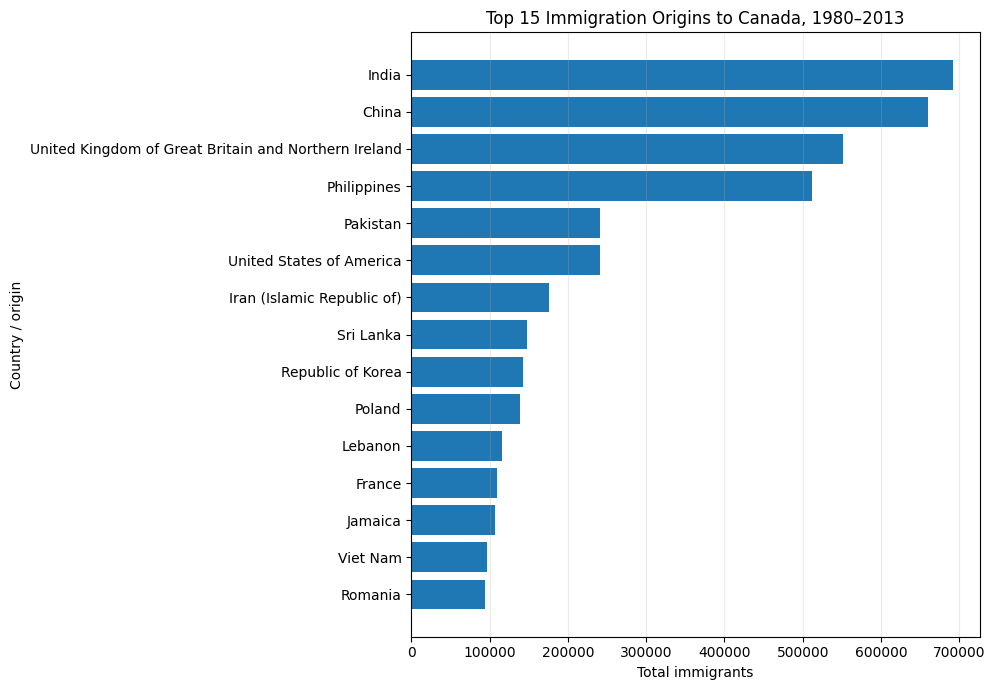

,Country,Continent,Region,Total
0,India,Asia,Southern Asia,691904
1,China,Asia,Eastern Asia,659962
2,United Kingdom of Great Britain and Northern I...,Europe,Northern Europe,551500
3,Philippines,Asia,South-Eastern Asia,511391
4,Pakistan,Asia,Southern Asia,241600
5,United States of America,Northern America,Northern America,241122
6,Iran (Islamic Republic of),Asia,Southern Asia,175923
7,Sri Lanka,Asia,Southern Asia,148358
8,Republic of Korea,Asia,Eastern Asia,142581
9,Poland,Europe,Eastern Europe,139241


In [4]:
top15 = (
    df[["Country", "Total"]]
    .nlargest(15, "Total")
    .sort_values("Total", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15["Country"], top15["Total"])

ax.set_title("Top 15 Immigration Origins to Canada, 1980–2013")
ax.set_xlabel("Total immigrants")
ax.set_ylabel("Country / origin")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

display(
    df[["Country", "Continent", "Region", "Total"]]
    .nlargest(15, "Total")
    .reset_index(drop=True)
)


### Interpretation

The cumulative ranking reveals a clear hierarchy. **India and China are the two largest origins**, followed by the **United Kingdom** and the **Philippines**. The fifth-ranked origin, Pakistan, is substantially below the first four.

This distribution suggests that overall immigration is not evenly spread across all origins. Later in the notebook, a cumulative concentration analysis quantifies how strongly the largest countries dominate the total.


## 4. How did the trajectories of the largest origin countries differ?

Cumulative totals alone can conceal very different historical paths.  
The five largest origins are therefore compared as annual time series.


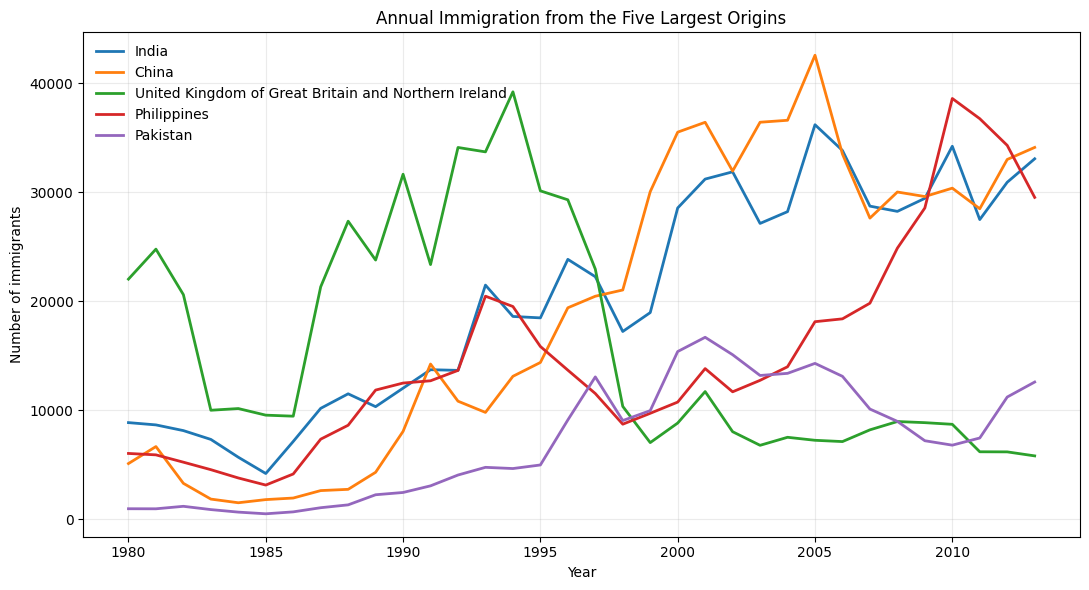

,Country,Total,Peak year,Peak annual value,1980,2013
0,India,691904,2005,36210,8880,33087
1,China,659962,2005,42584,5123,34129
2,United Kingdom of Great Britain and Northern I...,551500,1994,39231,22045,5827
3,Philippines,511391,2010,38617,6051,29544
4,Pakistan,241600,2001,16708,978,12603


In [5]:
top5_countries = df.nlargest(5, "Total")["Country"].tolist()

fig, ax = plt.subplots(figsize=(11, 6))

for country in top5_countries:
    values = df_can.loc[country, years].astype(float).values
    ax.plot(year_values, values, linewidth=2, label=country)

ax.set_title("Annual Immigration from the Five Largest Origins")
ax.set_xlabel("Year")
ax.set_ylabel("Number of immigrants")
ax.legend(frameon=False)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

trajectory_summary = []
for country in top5_countries:
    s = df_can.loc[country, years].astype(float)
    trajectory_summary.append(
        {
            "Country": country,
            "Total": int(df_can.loc[country, "Total"]),
            "Peak year": int(s.idxmax()),
            "Peak annual value": int(s.max()),
            "1980": int(s["1980"]),
            "2013": int(s["2013"]),
        }
    )

display(pd.DataFrame(trajectory_summary))


### Interpretation

The ranking hides meaningful differences in timing:

- India and China both became major sources, but their annual paths were not identical.
- The United Kingdom began at a comparatively high level and declined over much of the period.
- The Philippines rose strongly and reached its highest annual value later than China and India.
- Pakistan's total is lower than the top four, but its trajectory includes a pronounced rise from a much smaller 1980 base.

The important analytical distinction is therefore between **cumulative importance** and **temporal pattern**.


## 5. How did the continental composition of immigration change?

Country-level trajectories can be aggregated into broader geographic structures.  
A stacked area chart is appropriate here because the analytical goal is to show both:

- the changing total volume through time; and
- the contribution of each continent to that total.

This is a compositional use of an area chart, rather than using area simply as an alternative styling for a line chart.


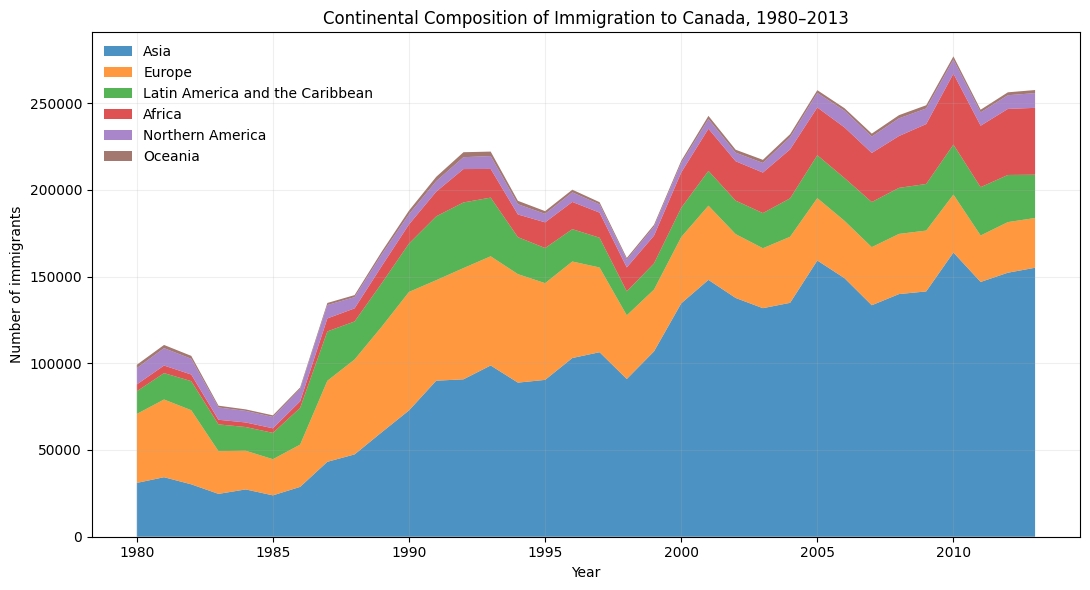

In [6]:
continent_yearly = (
    df.groupby("Continent")[years]
    .sum()
    .T
)

continent_yearly.index = continent_yearly.index.astype(int)
continent_yearly = continent_yearly[
    continent_yearly.sum(axis=0).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(11, 6))
ax.stackplot(
    continent_yearly.index,
    *[continent_yearly[col].values for col in continent_yearly.columns],
    labels=continent_yearly.columns,
    alpha=0.8,
)

ax.set_title("Continental Composition of Immigration to Canada, 1980–2013")
ax.set_xlabel("Year")
ax.set_ylabel("Number of immigrants")
ax.legend(loc="upper left", frameon=False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [7]:
continent_totals = (
    df.groupby("Continent")["Total"]
    .sum()
    .sort_values(ascending=False)
    .to_frame("Total")
)

continent_totals["Share (%)"] = (
    continent_totals["Total"] / continent_totals["Total"].sum() * 100
).round(1)

composition_1980 = (
    df.groupby("Continent")["1980"].sum()
    / df["1980"].sum() * 100
).round(1)

composition_2013 = (
    df.groupby("Continent")["2013"].sum()
    / df["2013"].sum() * 100
).round(1)

continent_totals["Share in 1980 (%)"] = composition_1980
continent_totals["Share in 2013 (%)"] = composition_2013

display(continent_totals)


,Total,Share (%),Share in 1980 (%),Share in 2013 (%)
Continent,,,,
Asia,3317794,51.8,31.3,60.2
Europe,1410947,22.0,40.1,11.1
Latin America and the Caribbean,765148,11.9,13.2,9.7
Africa,618948,9.7,4.0,15.0
Northern America,241122,3.8,9.5,3.3
Oceania,55174,0.9,2.0,0.7


### Interpretation

The continental structure changed substantially over the observation period.

Asia accounts for the largest cumulative share of identified international immigration and became much more dominant by the end of the series. Europe moved in the opposite direction: it represented a much larger share in 1980 than in 2013.

This shift shows why a country ranking alone is insufficient—the composition of Canadian immigration changed at a broader geographic level as well.


## 6. How unevenly was immigration distributed across countries in 2013?

The annual national total does not reveal whether immigration was broadly distributed across many origins or concentrated in a smaller number of countries.

A histogram provides a distributional view of country-level immigration counts in 2013. Because the distribution is highly right-skewed, the plot focuses on the country counts themselves while the numerical summary below reports the median, quartiles, and maximum explicitly.


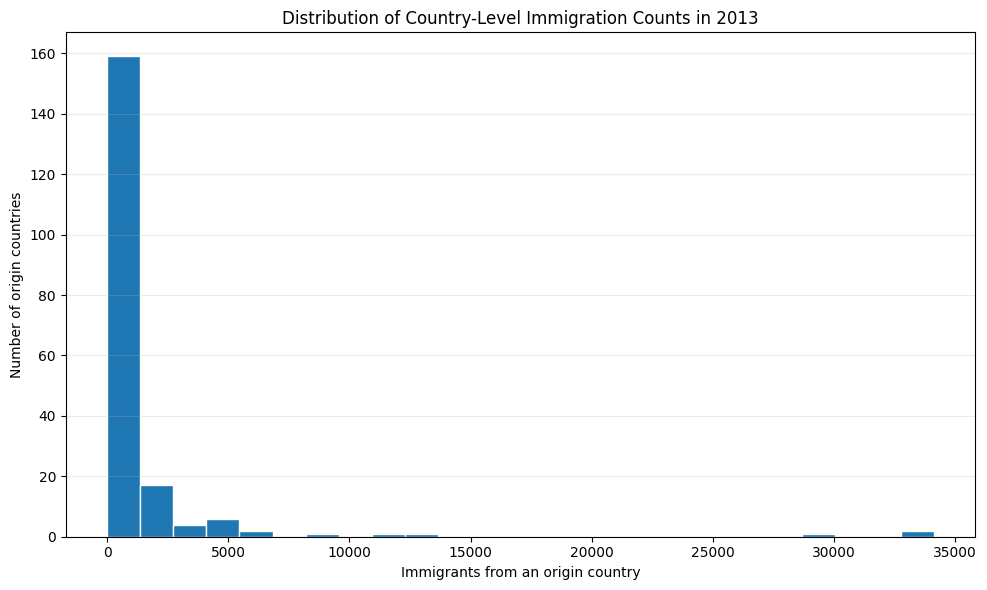

,2013 immigration
count,194.000000
mean,1327.500000
std,4247.851056
min,0.000000
25%,45.250000
50%,215.000000
75%,807.000000
max,34129.000000


Countries with zero recorded immigrants in 2013: 11
Median country-level count in 2013: 215
Maximum country-level count in 2013: 34,129


In [8]:
values_2013 = df["2013"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(values_2013, bins=25, edgecolor="white")

ax.set_title("Distribution of Country-Level Immigration Counts in 2013")
ax.set_xlabel("Immigrants from an origin country")
ax.set_ylabel("Number of origin countries")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

distribution_summary = values_2013.describe().to_frame("2013 immigration")
display(distribution_summary)

print(f"Countries with zero recorded immigrants in 2013: {(values_2013 == 0).sum()}")
print(f"Median country-level count in 2013: {values_2013.median():,.0f}")
print(f"Maximum country-level count in 2013: {values_2013.max():,.0f}")


### Interpretation

The 2013 distribution is strongly right-skewed: most origins recorded comparatively modest counts, while a small number of countries contributed very large flows.

The median is therefore far below the maximum. This is an important visual and statistical reminder that the national immigration total is driven disproportionately by a subset of origins.


## 7. How concentrated were total immigrant flows among the largest origins?

To quantify the concentration suggested by the ranking and histogram, countries are ordered by cumulative immigration and their cumulative share of the overall total is calculated.

This is essentially a **Pareto-style concentration curve**: it answers how many origins are required to account for a given share of total immigration.


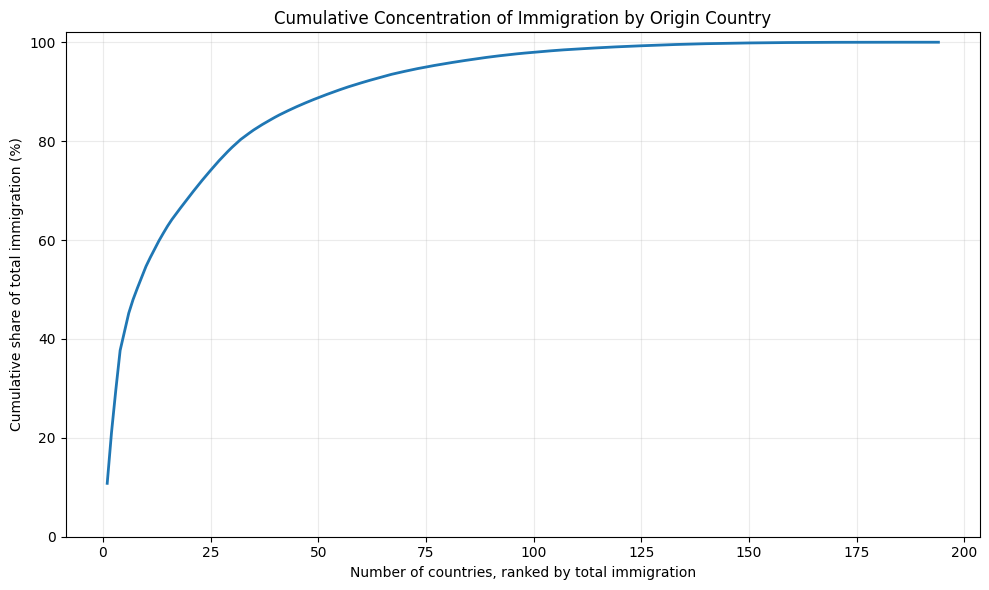

,Cumulative share,Countries required,Country at threshold,Actual cumulative share (%)
0,50%,8,Sri Lanka,50.3
1,75%,26,Germany,75.1
2,80%,32,Trinidad and Tobago,80.3
3,90%,54,Cuba,90.1


In [9]:
ranked = df[["Country", "Total"]].sort_values("Total", ascending=False).reset_index(drop=True)
ranked["Rank"] = np.arange(1, len(ranked) + 1)
ranked["Cumulative_Share"] = ranked["Total"].cumsum() / ranked["Total"].sum() * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ranked["Rank"], ranked["Cumulative_Share"], linewidth=2)

ax.set_title("Cumulative Concentration of Immigration by Origin Country")
ax.set_xlabel("Number of countries, ranked by total immigration")
ax.set_ylabel("Cumulative share of total immigration (%)")
ax.set_ylim(0, 102)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

threshold_rows = []
for threshold in [50, 75, 80, 90]:
    idx = ranked["Cumulative_Share"].ge(threshold).idxmax()
    threshold_rows.append(
        {
            "Cumulative share": f"{threshold}%",
            "Countries required": int(ranked.loc[idx, "Rank"]),
            "Country at threshold": ranked.loc[idx, "Country"],
            "Actual cumulative share (%)": round(ranked.loc[idx, "Cumulative_Share"], 1),
        }
    )

display(pd.DataFrame(threshold_rows))


### Interpretation

The concentration curve confirms that immigration was highly uneven across origins.

Only a small fraction of the 194 identified origins accounts for a large share of the cumulative total. This provides a stronger quantitative basis for the dominance visible in the top-country ranking and demonstrates why both **ranked comparison** and **distribution/concentration analysis** are useful.


## 8. Which major origin countries were the most variable over time?

A large cumulative total does not necessarily imply a stable annual flow.  
To compare temporal variability among the largest origins, the analysis computes:

- mean annual immigration;
- standard deviation across years;
- coefficient of variation (`standard deviation / mean`).

The scatter plot below places average annual immigration on the x-axis and relative variability on the y-axis. Marker size reflects cumulative immigration, allowing three quantities to be examined simultaneously without introducing a separate modeling exercise.


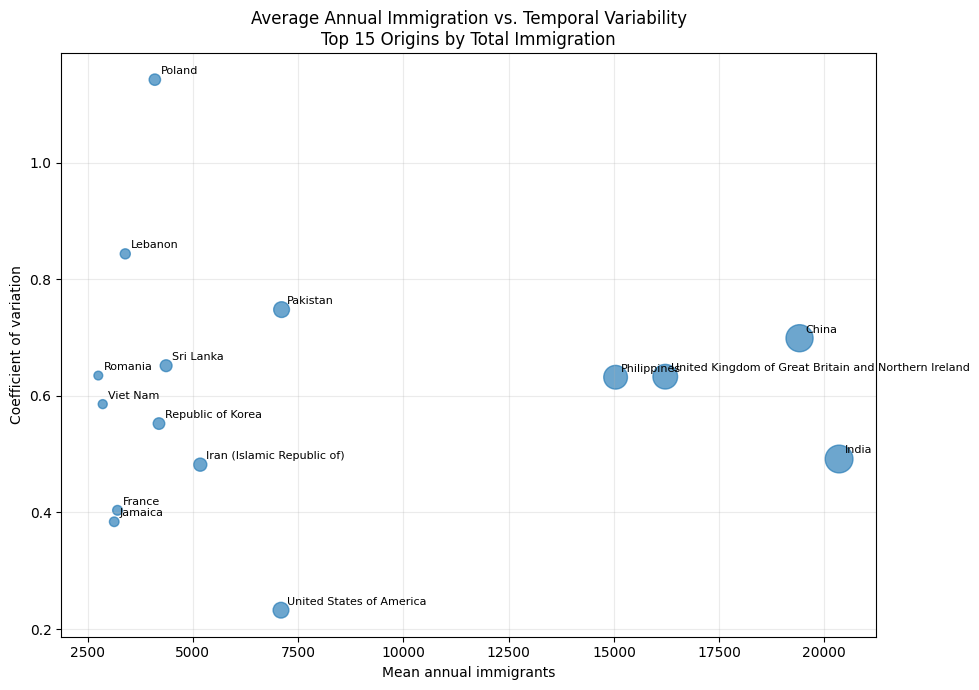

,Mean_Annual,Std_Annual,CV,Total
Country,,,,
Poland,4095.3,4679.3,1.14,139241
Lebanon,3392.9,2862.8,0.84,115359
Pakistan,7105.9,5315.8,0.75,241600
China,19410.6,13568.2,0.70,659962
Sri Lanka,4363.5,2844.3,0.65,148358
Romania,2752.5,1747.7,0.63,93585
United Kingdom of Great Britain and Northern Ireland,16220.6,10267.7,0.63,551500
Philippines,15040.9,9506.8,0.63,511391
Viet Nam,2857.2,1674.1,0.59,97146


In [10]:
major = df.nlargest(15, "Total").set_index("Country")

variability = pd.DataFrame(index=major.index)
variability["Mean_Annual"] = major[years].mean(axis=1)
variability["Std_Annual"] = major[years].std(axis=1)
variability["CV"] = variability["Std_Annual"] / variability["Mean_Annual"]
variability["Total"] = major["Total"]

marker_sizes = 40 + 360 * (
    (variability["Total"] - variability["Total"].min())
    / (variability["Total"].max() - variability["Total"].min())
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    variability["Mean_Annual"],
    variability["CV"],
    s=marker_sizes,
    alpha=0.65,
)

for country, row in variability.iterrows():
    ax.annotate(
        country,
        (row["Mean_Annual"], row["CV"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Average Annual Immigration vs. Temporal Variability\nTop 15 Origins by Total Immigration")
ax.set_xlabel("Mean annual immigrants")
ax.set_ylabel("Coefficient of variation")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

display(
    variability.sort_values("CV", ascending=False)
    .round({"Mean_Annual": 1, "Std_Annual": 1, "CV": 2})
)


### Interpretation

The scatter shows that scale and stability are separate characteristics.

Some major origins combine high average annual flows with substantial variability, while others are comparatively stable. 


## 9. Focused case: Haiti and the 2010 earthquake period

Here we focus on the post-2010 rise in Haitian immigration with Canada's response following the catastrophic 2010 Haiti earthquake.


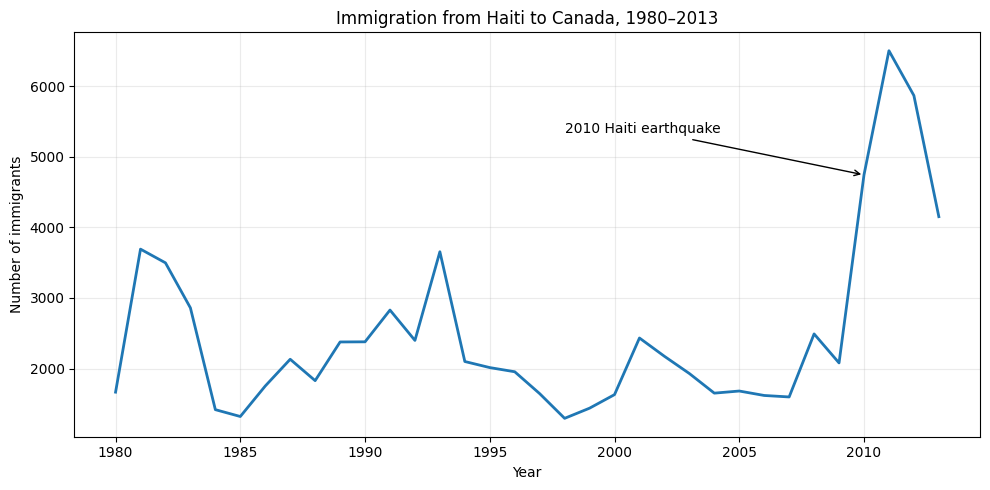

Haiti immigration: 2009 = 2,080, 2010 = 4,744, 2011 = 6,503.


In [11]:
haiti = df_can.loc["Haiti", years].astype(float)
haiti.index = haiti.index.astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(haiti.index, haiti.values, linewidth=2)

ax.set_title("Immigration from Haiti to Canada, 1980–2013")
ax.set_xlabel("Year")
ax.set_ylabel("Number of immigrants")
ax.grid(alpha=0.25)

ax.annotate(
    "2010 Haiti earthquake",
    xy=(2010, haiti.loc[2010]),
    xytext=(1998, haiti.max() * 0.82),
    arrowprops={"arrowstyle": "->"},
)

plt.tight_layout()
plt.show()

print(
    f"Haiti immigration: 2009 = {int(haiti.loc[2009]):,}, "
    f"2010 = {int(haiti.loc[2010]):,}, "
    f"2011 = {int(haiti.loc[2011]):,}."
)


We can see there is a dramatic increase of immegration from Haiti to Canada around 2010. As we search for large events happening in year 2010, the 2010 Haiti earthquake explains and confirms our finding.

## 10. Exploratory findings

The combined visual evidence supports several high-level findings:

1. **Immigration increased over the long run but not smoothly.** Annual totals varied considerably across 1980–2013 and reached their highest level in 2010.
2. **A relatively small group of countries dominated cumulative immigration.** India, China, the United Kingdom, and the Philippines were especially important sources.
3. **The largest countries followed different temporal paths.** Similar cumulative totals can conceal different peaks, growth periods, and declines.
4. **The geographic composition shifted markedly toward Asia.** Europe's relative contribution was much larger near the beginning of the series, whereas Asia dominated by 2013.
5. **Country-level immigration was highly right-skewed.** Most origins contributed relatively modest annual counts, while a small number contributed very large flows.
6. **Concentration was substantial.** A minority of origins accounted for most cumulative immigration.
7. **Scale and volatility were distinct.** Major source countries differed substantially in the stability of their annual flows.

These findings are descriptive rather than causal. The visualizations identify patterns, contrasts, concentration, and temporal change, but they do not establish why those patterns occurred.


## 11. Visualization design choices

The notebook intentionally uses a limited set of chart types, each matched to an analytical task:

| Analytical task | Visualization |
|---|---|
| Trend through ordered time | Line chart |
| Ranking countries | Horizontal bar chart |
| Comparing country trajectories | Multi-series line chart |
| Composition through time | Stacked area chart |
| Distribution across origins | Histogram |
| Cumulative concentration | Ranked cumulative line |
| Relationship among quantitative properties | Scatter / bubble-style chart |
| Historical event context | Annotated line chart |

**Next:** Notebook 03 will extend the project with selected statistical and advanced visualization techniques where they provide additional insight.
